In [ ]:
!pip install holiday_jp

  Preparing metadata (setup.py) ... done
  Created wheel for holiday_jp: filename=holiday_jp-22.10.31-py3-none-any.whl size=13737 sha256=fc935c71a46102811af74cdba86f7e20744971f977bbefd0c54efbcb3c97dc31
  Stored in directory: /root/.cache/pip/wheels/f8/63/12/d13a33863f88a460ab4c20f745b456627a79ccfcc326960392
Successfully built holiday_jp


Importing all the necessary Libraries

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.impute import KNNImputer
import duckdb
from sklearn.ensemble import RandomForestRegressor
from holiday_jp import HolidayJp

In [ ]:
hikone = pd.read_csv("hikone.csv")
kobe = pd.read_csv("kobe.csv")
kyoto = pd.read_csv("kyoto.csv")
nara = pd.read_csv("nara.csv")
osaka = pd.read_csv("osaka.csv")
shionomisaki = pd.read_csv("shionomisaki.csv")
toyooka = pd.read_csv("toyooka.csv")
wakayama = pd.read_csv("wakayama.csv")

In [ ]:
hikone.head(2)

,datetime,precipitation,temperature,dew_point_temperature,humidity,wind_speed,wind_direction,snowfall
0,01-01-2021 00:00,0.0,0.3,-4.9,68,3.8,南,0
1,01-01-2021 01:00,0.0,0.3,-4.7,69,3.7,南南西,0


In [ ]:
kobe.head(2)

,datetime,precipitation,temperature,dew_point_temperature,humidity,wind_speed,wind_direction,snowfall
0,01-01-2021 00:00,0.0,2.2,-3.7,65,5.7,西,0
1,01-01-2021 01:00,0.0,2.5,-3.4,65,4.3,西南西,0


In [ ]:
kyoto.head()

,datetime,precipitation,temperature,dew_point_temperature,humidity,wind_speed,wind_direction,snowfall
0,2021-01-01 00:00:00,0.0,0.6,-5.0,66.0,2.1,南南西,0.0
1,2021-01-01 01:00:00,0.0,0.5,-4.9,67.0,1.5,南南西,0.0
2,2021-01-01 02:00:00,0.0,0.2,-5.0,68.0,0.9,北東,0.0
3,2021-01-01 03:00:00,0.0,0.0,-4.6,71.0,1.8,南,0.0
4,2021-01-01 04:00:00,0.0,0.0,-4.6,71.0,2.3,北西,0.0


In [ ]:
nara.shape

(0, 8)

In [ ]:
osaka.head(2)

,datetime,precipitation,temperature,dew_point_temperature,humidity,wind_speed,wind_direction,snowfall
0,01-01-2021 00:00,0.0,3.1,-4.1,59,4.8,西南西,0
1,01-01-2021 01:00,0.0,3.0,-3.8,61,4.0,西南西,0


In [ ]:
shionomisaki.head(2)

,datetime,precipitation,temperature,dew_point_temperature,humidity,wind_speed,wind_direction,snowfall
0,01-01-2021 00:00,0.0,3.7,-4.2,56,6.7,西北西,0
1,01-01-2021 01:00,0.0,4.1,-3.6,57,8.0,西北西,0


In [ ]:
toyooka.head(2)

,datetime,precipitation,temperature,dew_point_temperature,humidity,wind_speed,wind_direction,snowfall
0,2021-01-01 00:00:00,0.5,-0.3,-0.4,99.0,2.1,南南東,1.0
1,2021-01-01 01:00:00,1.5,-0.2,-0.3,99.0,2.0,南,2.0


In [ ]:
wakayama.head(2)

,datetime,precipitation,temperature,dew_point_temperature,humidity,wind_speed,wind_direction,snowfall
0,2021-01-01 00:00:00,0.0,2.3,-1.0,79.0,2.6,西南西,0.0
1,2021-01-01 01:00:00,0.0,3.1,-2.2,68.0,1.5,北,0.0


There is no data for nara

In [ ]:
hikone["datetime"] = pd.to_datetime(hikone["datetime"], format="%d-%m-%Y %H:%M")
kobe["datetime"] = pd.to_datetime(kobe["datetime"], format="%d-%m-%Y %H:%M")
#apply these for those where they are required

Creating a Column City for each dataset.

In [ ]:
cities = [hikone, kobe, kyoto, nara, osaka, shionomisaki, toyooka, wakayama]
city_names = ["hikone", "kobe", "kyoto", "nara", "osaka", "shionomisaki", "toyooka", "wakayama"]

# Add the respective city name to each dataframe
for city, name in zip(cities, city_names):
    city["city"] = name  # Add new column with the city name

# Combine all dataframes, aligning on 'datetime' and stacking the data
df = pd.concat(cities, axis=0, ignore_index=True)

# Sort the combined dataframe by 'datetime' and reset index
df["datetime"] = pd.to_datetime(df["datetime"])  # Ensure datetime is in datetime format

# df = df.sort_values(by="datetime").reset_index(drop=True)

<ipython-input-155-6da0173d0ed9>:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat(cities, axis=0, ignore_index=True)


In [ ]:
# if datetime is not in sorted order then use that
df = df.sort_values(by="datetime").reset_index(drop=True)

In [ ]:
df.head(20)

,datetime,precipitation,temperature,dew_point_temperature,humidity,wind_speed,wind_direction,snowfall,city
0,2021-01-01 00:00:00,0.0,0.3,-4.9,68.0,3.8,南,0.0,hikone
1,2021-01-01 00:00:00,0.0,0.6,-5.0,66.0,2.1,南南西,0.0,kyoto
2,2021-01-01 00:00:00,0.0,3.7,-4.2,56.0,6.7,西北西,0.0,shionomisaki
3,2021-01-01 00:00:00,0.5,-0.3,-0.4,99.0,2.1,南南東,1.0,toyooka
4,2021-01-01 00:00:00,0.0,2.2,-3.7,65.0,5.7,西,0.0,kobe
5,2021-01-01 00:00:00,0.0,2.3,-1.0,79.0,2.6,西南西,0.0,wakayama
6,2021-01-01 00:00:00,0.0,3.1,-4.1,59.0,4.8,西南西,0.0,osaka
7,2021-01-01 01:00:00,0.0,3.0,-3.8,61.0,4.0,西南西,0.0,osaka
8,2021-01-01 01:00:00,0.0,2.5,-3.4,65.0,4.3,西南西,0.0,kobe
9,2021-01-01 01:00:00,0.0,0.5,-4.9,67.0,1.5,南南西,0.0,kyoto


In [ ]:
df = df.drop(columns="city")
# we have to drop city column for aggregating

In [ ]:
df["wind_direction"].groupby(df["wind_direction"]).count()

,wind_direction
wind_direction,
×,43
北,15496
北北東,13652
北北西,13211
北北西 ),2
北東,15024
北西,12932
南,9203
南南東,9378


In [ ]:
df.loc[df["wind_direction"] == '東北東 )', "wind_direction"] = '東北東'
df.loc[df["wind_direction"] == '西 )', "wind_direction"] = '西'
df.loc[df["wind_direction"] == '北北西 )', "wind_direction"] = '北北西'

In [ ]:
wind_directions_japanese_mapping = {
    "南": 180,  # South
    "西南西": -157.5,  # South-Southwest
    "西北西": -67.5,  # West-Northwest
    "南南東": 157.5,  # South-Southeast
    "西": -90,  # West
    "北": 0,  # North
    "北東": 45,  # Northeast
    "南西": -135,  # Southwest
    "北西": -45,  # Northwest
    "北北西": -22.5,  # North-Northwest
    "東南東": 112.5,  # East-Southeast
    "東": 90,  # East
    "静穏": np.nan,  # Calm (no wind direction)
    "南東": 135,  # Southeast
    "東北東": 67.5,  # East-Northeast
    "北北東": 22.5,  # North-Northeast
    "西南西": -112.5,  # West-Southwest
    "×": np.nan  # Invalid entry
}

df["wind_direction"] = df["wind_direction"].map(wind_directions_japanese_mapping)
# go with 0 to 360 degree for assigning and do create two columns for sin and cos of this column and then remove this column

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183960 entries, 0 to 183959
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   datetime               183960 non-null  datetime64[ns]
 1   precipitation          183960 non-null  float64       
 2   temperature            183960 non-null  float64       
 3   dew_point_temperature  183960 non-null  float64       
 4   humidity               183960 non-null  float64       
 5   wind_speed             183960 non-null  float64       
 6   wind_direction         174006 non-null  float64       
 7   snowfall               183960 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 11.2 MB


Implementing KNN Imputer to fill those missing values since wind_direction depends on its nearby values

In [ ]:
# KNN imputer works good for categorical data
knn_imputer = KNNImputer(n_neighbors=5)
knn_imputer.fit(df[['wind_direction']])
df["wind_direction"] = pd.DataFrame(knn_imputer.transform(df[['wind_direction']]))

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183960 entries, 0 to 183959
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   datetime               183960 non-null  datetime64[ns]
 1   precipitation          183960 non-null  float64       
 2   temperature            183960 non-null  float64       
 3   dew_point_temperature  183960 non-null  float64       
 4   humidity               183960 non-null  float64       
 5   wind_speed             183960 non-null  float64       
 6   wind_direction         183960 non-null  float64       
 7   snowfall               183960 non-null  float64       
dtypes: datetime64[ns](1), float64(7)
memory usage: 11.2 MB


In [ ]:
df.head(10)

,datetime,precipitation,temperature,dew_point_temperature,humidity,wind_speed,wind_direction,snowfall
0,2021-01-01 00:00:00,0.0,0.3,-4.9,68.0,3.8,180.000000,0.0
1,2021-01-01 00:00:00,0.0,0.6,-5.0,66.0,2.1,11.770198,0.0
2,2021-01-01 00:00:00,0.0,3.7,-4.2,56.0,6.7,-67.500000,0.0
3,2021-01-01 00:00:00,0.5,-0.3,-0.4,99.0,2.1,157.500000,1.0
4,2021-01-01 00:00:00,0.0,2.2,-3.7,65.0,5.7,-90.000000,0.0
5,2021-01-01 00:00:00,0.0,2.3,-1.0,79.0,2.6,-112.500000,0.0
6,2021-01-01 00:00:00,0.0,3.1,-4.1,59.0,4.8,-112.500000,0.0
7,2021-01-01 01:00:00,0.0,3.0,-3.8,61.0,4.0,-112.500000,0.0
8,2021-01-01 01:00:00,0.0,2.5,-3.4,65.0,4.3,-112.500000,0.0
9,2021-01-01 01:00:00,0.0,0.5,-4.9,67.0,1.5,11.770198,0.0


**Why Aggregate Weather Data from All Locations?**

Since our electricity demand is reported as an aggregate value (combined for all locations), we aggregate the weather data to create a unified set of features that reflect overall environmental conditions. This approach:

- **Aligns with the Target:**  
  Aggregating ensures that our weather features correspond to the aggregated demand, providing a coherent signal.

- **Reduces Noise:**  
  By averaging (or otherwise aggregating) the data, we smooth out local anomalies and noise, focusing on the overall weather trends that impact demand.

- **Simplifies the Model:**  
  Aggregation reduces the feature space, making the model simpler and more robust while still capturing the essential influences of weather on electricity consumption.


In [ ]:
query = """
SELECT datetime, AVG(precipitation) AS Precipitation, AVG(temperature) Temperature, AVG(wind_speed) Wind_speed,
AVG(wind_direction) Wind_direction, AVG(humidity) Humidity, AVG(dew_point_temperature) Dew_point_temperature, AVG(snowfall) Snowfall
FROM df
GROUP BY datetime
ORDER BY datetime
"""
df = duckdb.query(query).df()
# Instead just taking averges, take mode mode sometime, or median

We convert wind direction into sine and cosine components because it's a circular variable. Directly using degrees can be misleading (since 0° and 360° are equivalent), but the sine and cosine transformation represents the direction on a continuous, cyclical scale. This transformation prevents discontinuities and allows models to learn the true spatial relationship in wind direction data.

In [ ]:
df["sine_wind_direction"] = np.sin(df["Wind_direction"] * np.pi / 180)
df["cosine_wind_direction"] = np.cos(df["Wind_direction"] * np.pi / 180)
df.drop(columns="Wind_direction", inplace=True)

In [ ]:
df["Year"] = df["datetime"].dt.year
df["Month"] = df["datetime"].dt.month
df["Day"] = df["datetime"].dt.day
df["Hour"] = df["datetime"].dt.hour

In [ ]:
df = df[[ 'Year', 'Month', 'Day', 'Hour', 'Precipitation', 'Temperature', 'Wind_speed', 'Humidity',
       'Dew_point_temperature', 'Snowfall', 'sine_wind_direction',
       'cosine_wind_direction']]
# datetime columns dropped

In [ ]:
df.head()
# first aggregate and then scale

,Year,Month,Day,Hour,Precipitation,Temperature,Wind_speed,Humidity,Dew_point_temperature,Snowfall,sine_wind_direction,cosine_wind_direction
0,2021,1,1,0,0.071429,1.700000,3.971429,70.285714,-3.328571,0.142857,-0.082758,0.996570
1,2021,1,1,1,0.214286,1.900000,3.571429,69.428571,-3.271429,0.285714,-0.219991,0.975502
2,2021,1,1,2,0.071429,1.928571,4.100000,68.000000,-3.557143,0.000000,-0.830748,0.556648
3,2021,1,1,3,0.142857,1.628571,3.857143,70.285714,-3.400000,0.285714,0.382683,0.923880
4,2021,1,1,4,0.071429,1.871429,3.814286,71.142857,-2.971429,0.000000,-0.506958,0.861971


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,26280.0,2022.000000,0.816512,2021.000000,2021.000000,2022.000000,2023.000000,2023.000000
Month,26280.0,6.526027,3.447917,1.000000,4.000000,7.000000,10.000000,12.000000
Day,26280.0,15.720548,8.796414,1.000000,8.000000,16.000000,23.000000,31.000000
Hour,26280.0,11.500000,6.922318,0.000000,5.750000,11.500000,17.250000,23.000000
Precipitation,26280.0,0.191283,0.683283,0.000000,0.000000,0.000000,0.071429,12.642857
Temperature,26280.0,17.073062,7.878136,-2.285714,10.785714,17.314286,23.571429,34.885714
Wind_speed,26280.0,2.902551,1.152264,0.642857,2.014286,2.671429,3.585714,11.957143
Humidity,26280.0,70.890884,12.788721,23.285714,62.000000,71.714286,80.428571,99.000000
Dew_point_temperature,26280.0,11.347242,8.266624,-10.242857,4.657143,11.200000,18.642857,25.928571
Snowfall,26280.0,0.004664,0.044657,0.000000,0.000000,0.000000,0.000000,2.000000


Three models : Random Forest, XGBoost, LSTM

**Justification for Model Choice:**  

- **Random Forest & XGBoost:** Handle non-linear relationships in weather and temporal data, providing feature importance insights.  
- **LSTM:** Captures sequential dependencies in hourly demand, essential for time-series forecasting.  

By combining tree-based models for interpretability and LSTMs for temporal learning, we aim to achieve accurate electricity demand forecasting.  

After experimenting with Random Forest, LSTM, and XGBoost, the **best results** were achieved using **XGBoost**.

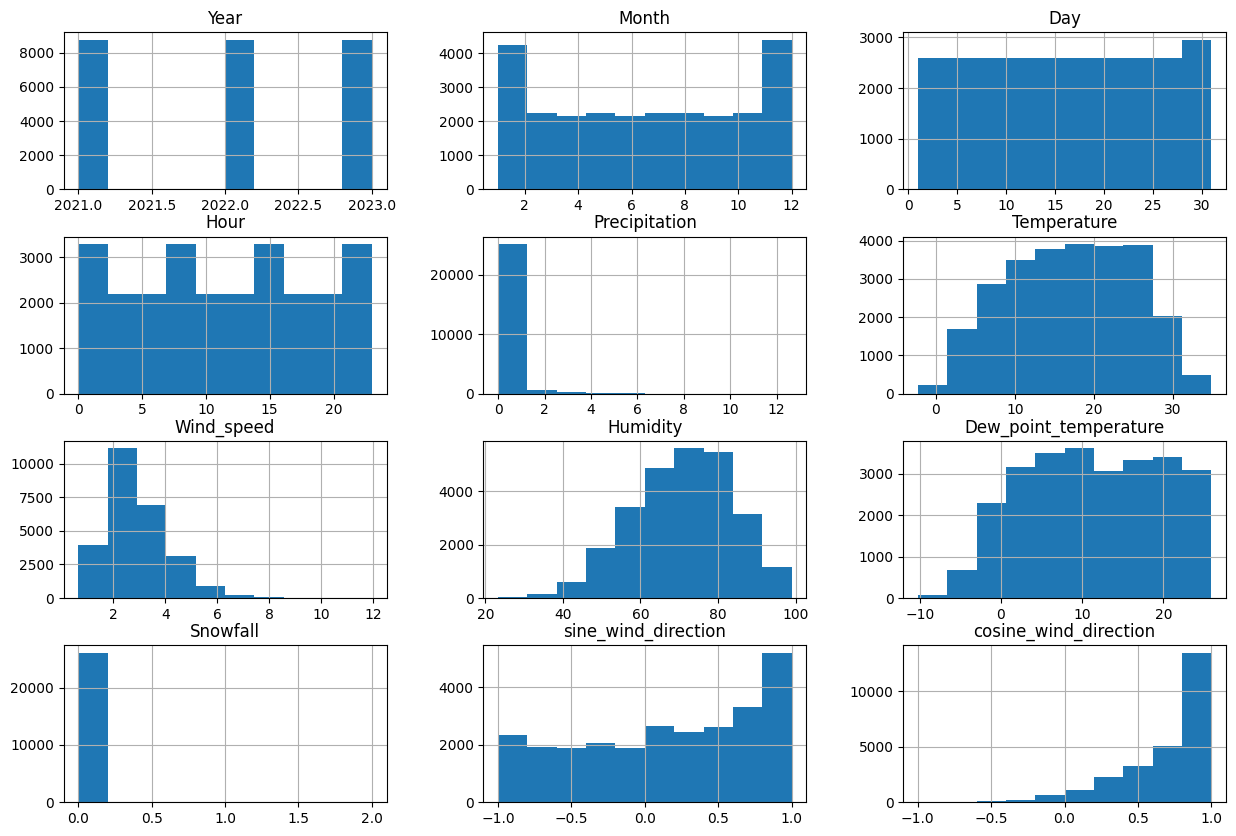

In [ ]:
df.hist(figsize=(15, 10))
plt.show()

None of the above models have a necessary condition to have must gaussian distribution.

<Axes: xlabel='Wind_speed', ylabel='Density'>

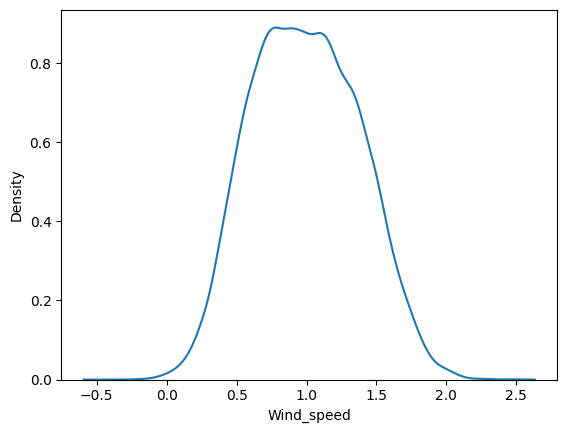

In [ ]:
sns.kdeplot(df["Wind_speed"].apply(np.log))

In [ ]:
df["Wind_speed"] = df["Wind_speed"].apply(np.log)

<ipython-input-89-60a9a5e98152>:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[column], ax=ax, shade=True)
<ipython-input-89-60a9a5e98152>:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[column], ax=ax, shade=True)
<ipython-input-89-60a9a5e98152>:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[column], ax=ax, shade=True)
<ipython-input-89-60a9a5e98152>:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[column], ax=ax, shade=True)
<ipython-input-89-60a9a5e98152>:7: FutureWarning: 

`sha

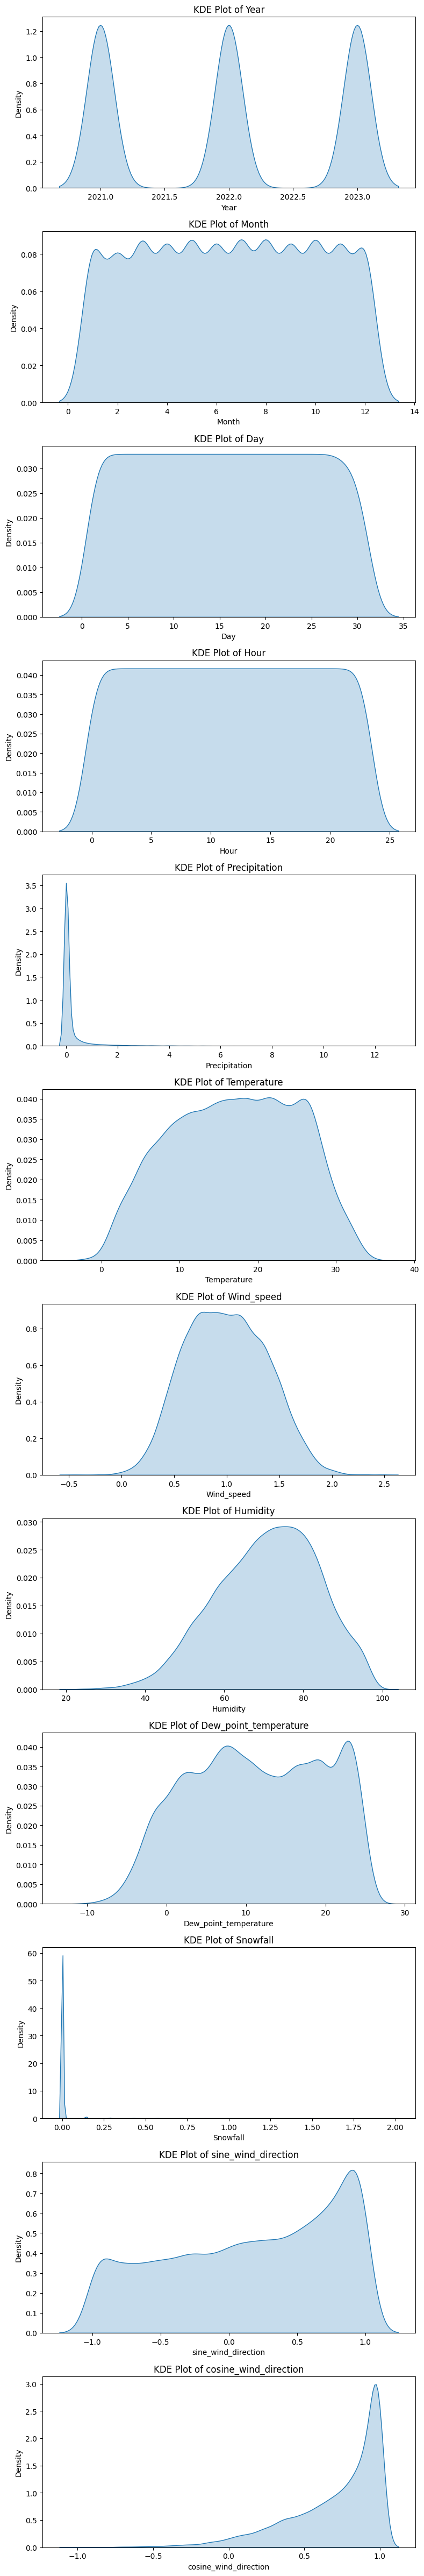

In [ ]:
num_columns = df.select_dtypes(include=["number"]).columns  # Select only numerical columns
num_plots = len(num_columns)

fig, axes = plt.subplots(nrows=num_plots, figsize=(8, 4 * num_plots))  # Create subplots

for ax, column in zip(axes, num_columns):
    sns.kdeplot(df[column], ax=ax, shade=True)
    ax.set_title(f"KDE Plot of {column}")

plt.tight_layout()
plt.show()

Scaling is not required for Random Forest and XGBoost\
They are necessary for LSTM

For Japan holidays seasonalities

In [ ]:
def is_holiday(date):
    year = date.Year
    month = date.Month
    day = date.Day
    datetime = pd.to_datetime(f"{year}-{month}-{day}")
    if HolidayJp(datetime).is_holiday:
       return 1
    else:
       return 0

df["is_holiday"] = df[["Year", "Month", "Day"]].apply(is_holiday, axis = 1)

In [ ]:
df

,Year,Month,Day,Hour,Precipitation,Temperature,Wind_speed,Humidity,Dew_point_temperature,Snowfall,sine_wind_direction,cosine_wind_direction,is_holiday
0,2021,1,1,0,0.071429,1.700000,1.379126,70.285714,-3.328571,0.142857,-0.082758,0.996570,1
1,2021,1,1,1,0.214286,1.900000,1.272966,69.428571,-3.271429,0.285714,-0.219991,0.975502,1
2,2021,1,1,2,0.071429,1.928571,1.410987,68.000000,-3.557143,0.000000,-0.830748,0.556648,1
3,2021,1,1,3,0.142857,1.628571,1.349927,70.285714,-3.400000,0.285714,0.382683,0.923880,1
4,2021,1,1,4,0.071429,1.871429,1.338753,71.142857,-2.971429,0.000000,-0.506958,0.861971,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26275,2023,12,31,19,0.714286,10.585714,1.717651,67.142857,4.514286,0.000000,-0.875223,0.483719,0
26276,2023,12,31,20,0.928571,10.485714,1.752920,66.428571,4.414286,0.000000,-0.943883,0.330279,0
26277,2023,12,31,21,0.285714,9.914286,1.667707,72.428571,5.071429,0.000000,-0.875223,0.483719,0
26278,2023,12,31,22,0.928571,9.642857,1.699540,75.285714,5.428571,0.000000,-0.644180,0.764874,0


**Hypotheses for Feature Engineering:**  

- **Temporal Features (Year, Month, Day, Hour):** Capture seasonality, daily patterns, and long-term trends in electricity demand.  
- **Wind Direction (Sine & Cosine Transformation):** Properly represents its cyclic nature, avoiding discontinuities.  
- **Aggregated Weather Data:** Ensures alignment with the combined electricity demand, reducing noise from individual locations.

In [ ]:
demand = pd.read_csv('demand.csv')
demand

,datetime,actual_performance(10000 kW)
0,01-01-2021 00:00,1571
1,01-01-2021 01:00,1492
2,01-01-2021 02:00,1453
3,01-01-2021 03:00,1412
4,01-01-2021 04:00,1358
...,...,...
26275,31-12-2023 19:00,1427
26276,31-12-2023 20:00,1392
26277,31-12-2023 21:00,1348
26278,31-12-2023 22:00,1288


In [ ]:
demand["datetime"] = pd.to_datetime(demand["datetime"], format="%d-%m-%Y %H:%M")
# Change datatiem format of demand
demand

,datetime,actual_performance(10000 kW)
0,2021-01-01 00:00:00,1571
1,2021-01-01 01:00:00,1492
2,2021-01-01 02:00:00,1453
3,2021-01-01 03:00:00,1412
4,2021-01-01 04:00:00,1358
...,...,...
26275,2023-12-31 19:00:00,1427
26276,2023-12-31 20:00:00,1392
26277,2023-12-31 21:00:00,1348
26278,2023-12-31 22:00:00,1288


In [ ]:
demand.describe()

,datetime,actual_performance(10000 kW)
count,26280,26280.000000
mean,2022-07-02 11:30:00,1616.426180
min,2021-01-01 00:00:00,955.000000
25%,2021-10-01 17:45:00,1359.000000
50%,2022-07-02 11:30:00,1572.000000
75%,2023-04-02 05:15:00,1816.000000
max,2023-12-31 23:00:00,2827.000000
std,NaN,328.186899


In [ ]:
demand.drop(columns="datetime", inplace=True)

In [ ]:
demand.rename(columns={"actual_performance(10000 kW)": "Demand"}, inplace=True)

# **Model** **Training**

In [ ]:
split_idx = int(0.66667 * len(df))  # Calculate split index

X_train, X_test = df.iloc[:split_idx], df.iloc[split_idx:]
y_train, y_test = demand.iloc[:split_idx], demand.iloc[split_idx:]

This Train test Split ensure 2023 jan 1 00:00 til 2023 dec 31 23:00 is left for evaluation. That is why split is done at 0.66667.

In [ ]:
y_train.head()

,Demand
0,1571
1,1492
2,1453
3,1412
4,1358


In [ ]:
y_train.tail()

,Demand
17515,1587
17516,1559
17517,1523
17518,1458
17519,1442


In [ ]:
y_test.head()

,Demand
17520,1380
17521,1331
17522,1327
17523,1310
17524,1267


In [ ]:
y_test.tail()

,Demand
26275,1427
26276,1392
26277,1348
26278,1288
26279,1258


In [ ]:
demand.dtypes

,0
Demand,int64


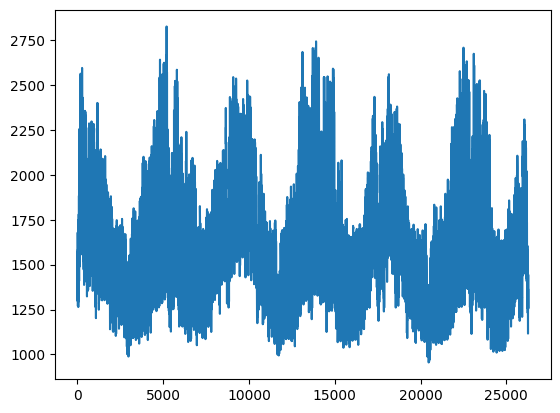

In [ ]:
plt.plot(demand["Demand"])

Random Forest

In [ ]:
RandomForest = RandomForestRegressor()
RandomForest.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestRegressor()

In [ ]:
RandomForest_preds = RandomForest.predict(X_train)
root_mean_squared_error(y_train, RandomForest_preds)
# root_mean_squared_error

32.988230006751046

In [ ]:
rnd_forest_cv_preds =  -cross_val_score(RandomForest, X_train, y_train, cv=10, scoring="neg_root_mean_squared_error")
rnd_forest_cv_preds.mean()
# cross validation

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

155.97287987518305

Hyperparameter Tuning using random search for Random Forest

In [ ]:
# Define the model
rf = RandomForestRegressor(random_state=42)

# Define the parameter grid
param_dist = {
    'n_estimators': np.arange(50, 500, 50),  # Number of trees
    'max_depth': np.arange(5, 30, 5),  # Depth of trees
    'min_samples_split': [2, 5, 7, 10, 15],  # Min samples to split
    'min_samples_leaf': [1, 2, 4, 7, 10],  # Min samples per leaf
    'max_features': ['sqrt', 'log2', None]  # Features per split
}

# Randomized Search CV
random_search = RandomizedSearchCV(
    rf, param_distributions=param_dist,
    n_iter=20,  # Number of combinations to try
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Minimize MSE
    n_jobs=-1,  # Use all processors
    random_state=42
)

# Fit the model
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", random_search.best_params_)

# Best model
best_rf3 = random_search.best_estimator_

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Best Parameters: {'n_estimators': 350, 'min_samples_split': 7, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 25}


In [ ]:
best_rf_cv_pred =  -cross_val_score(best_rf3, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
best_rf_cv_pred.mean()

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example usi

161.5652143891097

In [ ]:
final_preds = best_rf3.predict(X_test)
root_mean_squared_error(y_test, final_preds)

158.03835453508339

In [ ]:
mean_absolute_percentage_error(y_test, final_preds)*100

7.252455752521823

In [ ]:
y_test.reset_index(drop=True, inplace=True)

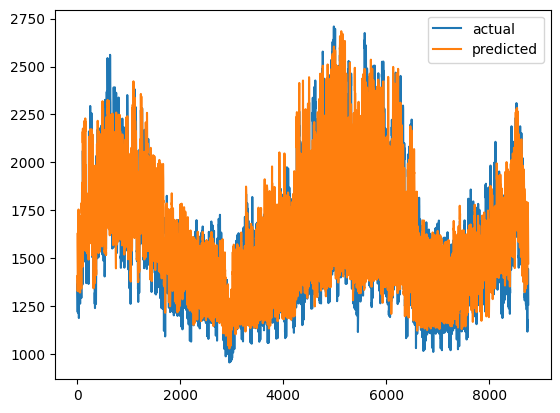

In [ ]:
plt.plot(y_test, label="actual")
plt.plot(final_preds, label="predicted")
plt.legend()
plt.show()

XGBoost

Hyperparameter Tuning

In [ ]:
# Define the model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Define the hyperparameter grid
param_dist = {
    'n_estimators': np.arange(100, 1000, 50),  # Number of trees
    'max_depth': np.arange(3, 15, 2),  # Depth of trees
    'learning_rate': np.linspace(0.01, 0.3, 10),  # Step size
    'subsample': np.linspace(0.5, 1.0, 5),  # Fraction of samples per tree
    'colsample_bytree': np.linspace(0.5, 1.0, 5),  # Fraction of features per tree
    'min_child_weight': [1, 3, 5, 7],  # Minimum sum of instance weight (for leaf)
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],  # Regularization parameter
    'reg_alpha': [0, 0.01, 0.1, 1, 10],  # L1 regularization (Lasso)
    'reg_lambda': [0, 0.01, 0.1, 1, 10]  # L2 regularization (Ridge)
}

# RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    xgb_model, param_distributions=param_dist,
    n_iter=30,  # Number of combinations to try
    cv=5,  # 5-fold cross-validation
    scoring='neg_mean_squared_error',  # Optimize for MSE
    n_jobs=-1,  # Use all available cores
    random_state=42
)

# Fit RandomizedSearchCV
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", random_search.best_params_)

# Best model
best_xgb = random_search.best_estimator_

Best Parameters: {'subsample': 0.5, 'reg_lambda': 10, 'reg_alpha': 10, 'n_estimators': 950, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 1.0}


In [ ]:
cv_xgb = -cross_val_score(best_xgb, X_train, y_train, cv=10, scoring='neg_root_mean_squared_error')
cv_xgb.mean()

144.95893325805665

In [ ]:
# Predictions
y_pred = best_xgb.predict(X_test)

In [ ]:
rmse = root_mean_squared_error(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 149.0297088623047


In [ ]:
mean_absolute_percentage_error(y_test, y_pred)*100

6.732176244258881

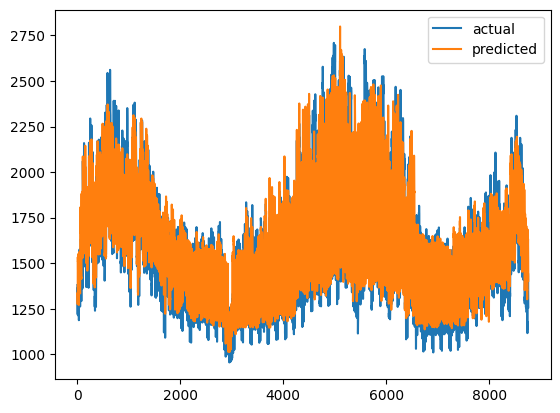

In [ ]:
plt.plot(y_test, label="actual")
plt.plot(y_pred, label="predicted")
plt.legend()
plt.show()

**Selected Evaluation Metrics & Justification:**  

- **Cross-Validation (CV):** Ensures the model generalizes well by validating performance across multiple data splits, reducing the risk of overfitting.  

- **Root Mean Squared Error (RMSE):**  
  - Penalizes large errors more than smaller ones, making it ideal for electricity demand forecasting where sudden spikes or drops need to be captured.  
  - Provides results in the same unit as the target (MW), making interpretation straightforward.  

- **Mean Absolute Percentage Error (MAPE):**  
  - Measures relative error, helping understand forecast accuracy in percentage terms.  
  - Useful for comparing errors across different demand levels, especially since electricity demand varies by season and time of day.  

**Issues Identified Through Error Analysis:**  

- **Lagged Effects Not Fully Captured:** Some demand fluctuations may be influenced by past weather patterns beyond the selected time window.  
- **Data Aggregation Limitations:** Aggregating weather data across locations may lose some local variations affecting electricity demand.  

Feature Importance for XGB model

<ipython-input-150-27cf50195bcb>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="viridis")


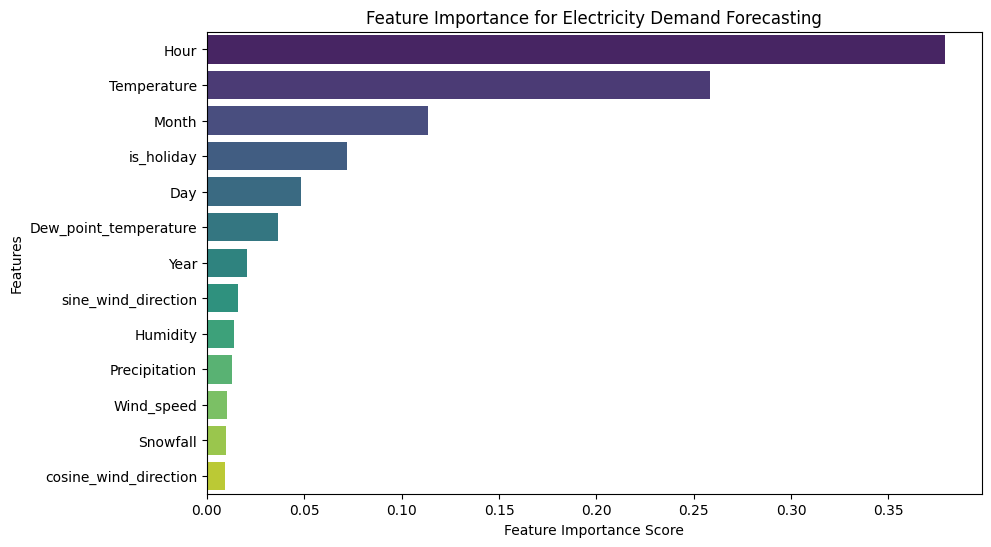

In [ ]:
# Get feature importance
feature_importance = pd.Series(best_xgb.feature_importances_, index=X_train.columns)

# Sort feature importance in descending order
feature_importance = feature_importance.sort_values(ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="viridis")

# Labels and title
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance for Electricity Demand Forecasting")
plt.show()

LSTM Model

In [ ]:
df_copy = df.copy()
demand_copy = demand.copy()

In [ ]:
# Transform time features into cyclical features
df_copy['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df_copy['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
df_copy['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df_copy['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df_copy.drop(columns = ["Hour", "Month"])

,Year,Day,Precipitation,Temperature,Wind_speed,Humidity,Dew_point_temperature,Snowfall,sine_wind_direction,cosine_wind_direction,is_holiday,Hour_sin,Hour_cos,Month_sin,Month_cos
0,2021,1,0.071429,1.700000,1.379126,70.285714,-3.328571,0.142857,-0.082758,0.996570,1,0.000000,1.000000,5.000000e-01,0.866025
1,2021,1,0.214286,1.900000,1.272966,69.428571,-3.271429,0.285714,-0.219991,0.975502,1,0.258819,0.965926,5.000000e-01,0.866025
2,2021,1,0.071429,1.928571,1.410987,68.000000,-3.557143,0.000000,-0.830748,0.556648,1,0.500000,0.866025,5.000000e-01,0.866025
3,2021,1,0.142857,1.628571,1.349927,70.285714,-3.400000,0.285714,0.382683,0.923880,1,0.707107,0.707107,5.000000e-01,0.866025
4,2021,1,0.071429,1.871429,1.338753,71.142857,-2.971429,0.000000,-0.506958,0.861971,1,0.866025,0.500000,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26275,2023,31,0.714286,10.585714,1.717651,67.142857,4.514286,0.000000,-0.875223,0.483719,0,-0.965926,0.258819,-2.449294e-16,1.000000
26276,2023,31,0.928571,10.485714,1.752920,66.428571,4.414286,0.000000,-0.943883,0.330279,0,-0.866025,0.500000,-2.449294e-16,1.000000
26277,2023,31,0.285714,9.914286,1.667707,72.428571,5.071429,0.000000,-0.875223,0.483719,0,-0.707107,0.707107,-2.449294e-16,1.000000
26278,2023,31,0.928571,9.642857,1.699540,75.285714,5.428571,0.000000,-0.644180,0.764874,0,-0.500000,0.866025,-2.449294e-16,1.000000


In [ ]:
df_copy.columns

Index(['Year', 'Month', 'Day', 'Hour', 'Precipitation', 'Temperature',
       'Wind_speed', 'Humidity', 'Dew_point_temperature', 'Snowfall',
       'sine_wind_direction', 'cosine_wind_direction', 'is_holiday',
       'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos'],
      dtype='object')

In [ ]:
# Select features and target
features = ['Year', 'Month', 'Day', 'Hour', 'Precipitation', 'Temperature',
       'Wind_speed', 'Humidity', 'Dew_point_temperature', 'Snowfall',
       'sine_wind_direction', 'cosine_wind_direction', 'is_holiday',
       'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos']

target = 'Demand'

# Scale data using MinMaxScaler (important for LSTMs)
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

df_copy[features] = scaler_x.fit_transform(df_copy[features])
demand_copy[target] = scaler_y.fit_transform(demand_copy[[target]])

# Function to create sequences for LSTM
def create_sequences(data, target, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(target[i + seq_length])
    return np.array(X), np.array(y)

# Create sequences
SEQ_LENGTH = 24  # Using past 24 hours to predict next value
X, y = create_sequences(df_copy[features].values, demand_copy[target].values, SEQ_LENGTH)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33333, random_state=42, shuffle=False)

# --- Define the Enhanced LSTM Model ---
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(SEQ_LENGTH, len(features))),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(64, activation='tanh', return_sequences=False),
    Dropout(0.2),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dense(1)  # Single output for regression
])

model.compile(optimizer='adam', loss='mse')

# --- Callbacks for Better Training ---
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

# Predict and inverse transform
y_pred = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred)
y_test = scaler_y.inverse_transform(y_test.reshape(-1, 1))

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.2031 - val_loss: 0.0125
Epoch 2/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0206 - val_loss: 0.0116
Epoch 3/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 0.0159 - val_loss: 0.0095
Epoch 4/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.0137 - val_loss: 0.0097
Epoch 5/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0118 - val_loss: 0.0100
Epoch 6/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0118 - val_loss: 0.0104
Epoch 7/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0102 - val_loss: 0.0131
Epoch 8/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0100 - val_loss: 0.0083
Epoch 9/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0094 - val_loss: 0.0104
Epoch 10/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0092 - val_loss: 0.0149
Epoch 11/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 0.0093 - val_loss: 0.0121
Epoch 12/50
547/547 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms

In [ ]:
root_mean_squared_error(y_test, y_pred)

195.94073778429038

In [ ]:
mean_absolute_percentage_error(y_test, y_pred)*100

9.377308056539196

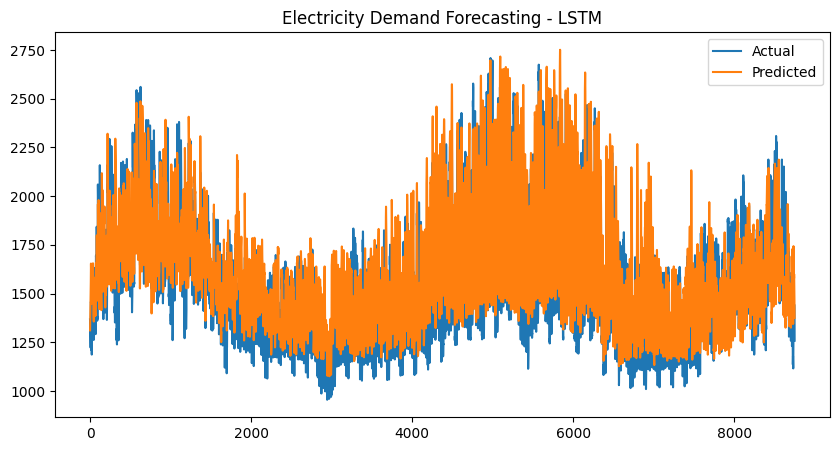

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Electricity Demand Forecasting - LSTM")
plt.show()

**Potential Strategies for Enhancing Model Performance:**  

### **For XGBoost:**  
- **Feature Selection:** Remove less relevant features to reduce noise and improve generalization.  
- **Adding Interaction Features:** Create new features capturing relationships between weather variables and time-based patterns.  

### **For Random Forest:**  
- **Increase Number of Trees:** Helps in reducing variance and improving stability.  
- **Feature Importance Analysis:** Use feature importance scores to eliminate less useful features.  
- **Handling Imbalanced Seasonal Data:** Weight samples differently based on demand fluctuations during peak and off-peak periods.  

### **For LSTM:**  
- **Longer Sequence Lengths:** Capture long-term dependencies in electricity demand trends.    
- **Hybrid Approach:** Combine LSTM with XGBoost for feature extraction and final prediction to leverage the strengths of both models.  

### **Potential Impact and Advantages of Implementing the Model**  

- **Improved Demand Forecasting:** Helps electricity providers anticipate fluctuations and optimize power generation, reducing supply-demand imbalances.  
- **Cost Savings:** More accurate predictions reduce reliance on costly last-minute energy procurement and help in efficient resource allocation.  
- **Grid Stability & Reliability:** Better forecasting minimizes the risk of power outages by ensuring a stable energy supply.  
- **Renewable Energy Integration:** Enhances planning for renewable energy sources like wind and solar by predicting demand alongside weather conditions.  
- **Operational Efficiency:** Utilities can plan maintenance and load balancing more effectively, reducing system stress during peak demand periods.  
- **Sustainability & Carbon Reduction:** Optimized energy management leads to reduced fuel wastage and lower carbon emissions.  